# 03 — Model Building & Evaluation
### A Multimodal Framework for Hateful Meme Detection
**Dataset:** Facebook Hateful Memes Challenge  
**Models:** CLIP · ResNet50+BERT (Late Fusion) · VisualBERT (Early Fusion)

## 1. Imports

In [1]:
import os, random, uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, f1_score,
    precision_score, recall_score
)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from transformers import (
    BertModel, BertTokenizer,
    VisualBertModel, VisualBertConfig,
    CLIPProcessor, CLIPModel
)

import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Google Colab Setup *(skip if running locally)*

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')

    rar_path   = '/content/drive/MyDrive/data.rar'
    target_dir = '/content/dataset'

    os.makedirs(target_dir, exist_ok=True)
    !unrar x "{rar_path}" "{target_dir}/"
    print(f"Extraction complete. Data is now in {target_dir}")
except ImportError:
    print("Not running on Google Colab — skipping drive mount.")

Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/data/raw/HM Dataset/img/49805.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49806.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49807.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49810.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49826.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49831.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49832.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49836.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49850.png            49%  OK 
Extracting  /content/dataset/data/raw/HM Dataset/img/49856.png            49%  OK 
Extracting  /content/dataset/

## 3. Global Configuration

In [3]:
class Config:
    seed            = 42
    img_size        = 224
    batch_size      = 32
    epochs          = 10        # Increase for real training
    lr_clip         = 1e-5
    lr_bert         = 2e-5
    weight_decay    = 1e-2
    patience        = 3         # Early-stopping patience
    max_len         = 77        # CLIP text max length
    max_len_bert    = 128       # BERT text max length
    grad_clip       = 1.0       # Gradient clipping norm
    num_workers     = 2

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pre-trained model identifiers
    clip_model_name       = "openai/clip-vit-base-patch32"
    bert_model_name       = "bert-base-uncased"
    visualbert_model_name = "uclanlp/visualbert-vqa-coco-pre"

    # ── Update these paths to match your environment ──────────────
    data_root  = "/content/dataset/data/raw/HM Dataset"
    train_path = "/content/dataset/data/processed/train_metadata.csv"
    dev_path   = "/content/dataset/data/processed/dev_metadata.csv"
    test_path  = "/content/dataset/data/processed/test_metadata.csv"

print(f"Using device: {Config.device}")

Using device: cuda


## 4. Reproducibility Seed

In [4]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(Config.seed)
print(f"Seed set to {Config.seed}")

Seed set to 42


## 5. Data Loading & Preprocessing

In [5]:
def load_and_preprocess_data(root_dir: str):
    """Load CSVs, fix image paths, and compute pos_weight for class imbalance."""
    try:
        train_df = pd.read_csv(Config.train_path)
        dev_df   = pd.read_csv(Config.dev_path)
        test_df  = pd.read_csv(Config.test_path)
    except FileNotFoundError as e:
        print(f"[ERROR] {e}\nCheck paths in Config.")
        return None, None, None, None

    def fix(df, split_name):
        # Normalize label column
        for col in ('labels', 'class'):
            if col in df.columns:
                df = df.rename(columns={col: 'label'})
        if 'label' not in df.columns:
            df['label'] = 0

        def resolve_path(img_val):
            fname = os.path.basename(str(img_val))
            if not fname.lower().endswith('.png'):
                fname += '.png'
            for p in [os.path.join(root_dir, 'img', fname),
                      os.path.join(root_dir, fname)]:
                if os.path.exists(p):
                    return p
            return None

        df = df.copy()
        df['full_path'] = df['img'].apply(resolve_path)
        missing = df['full_path'].isna().sum()
        df = df.dropna(subset=['full_path']).reset_index(drop=True)
        print(f"  [{split_name:5s}] {len(df):,} samples loaded  ({missing} images not found)")
        return df

    print("Loading splits ...")
    train_df = fix(train_df, "Train")
    dev_df   = fix(dev_df,   "Val")
    test_df  = fix(test_df,  "Test")

    # Class-imbalance weight for BCEWithLogitsLoss
    pos  = (train_df['label'] == 1).sum()
    neg  = (train_df['label'] == 0).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float).to(Config.device)
    print(f"\n  Class balance → Non-Hateful: {neg:,}  |  Hateful: {pos:,}")
    print(f"  pos_weight = {pos_weight.item():.3f}  (used in BCEWithLogitsLoss)")

    return train_df, dev_df, test_df, pos_weight

## 6. Image Transforms

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((Config.img_size, Config.img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((Config.img_size, Config.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms defined.")

Transforms defined.


## 7. Result Containers

In [7]:
# Stores per-epoch metrics for every model
model_histories: dict = {}

# Stores final scalar metrics for comparison chart
model_comparison = {'Model': [], 'Accuracy': [], 'AUC': [], 'F1': []}

print("Result containers initialised.")

Result containers initialised.


## 8. Dataset Classes

In [8]:
# ═══════════════════════════════════════════════════════════════
# 8-A  CLIP Dataset
# ═══════════════════════════════════════════════════════════════
class CLIPDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.df        = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        inp   = self.processor(
            text=str(row['text']),
            images=image,
            return_tensors="pt",
            padding="max_length",
            max_length=Config.max_len,
            truncation=True
        )
        return {
            'input_ids':      inp['input_ids'].squeeze(0),
            'attention_mask': inp['attention_mask'].squeeze(0),
            'pixel_values':   inp['pixel_values'].squeeze(0),
            'label':          torch.tensor(row['label'], dtype=torch.float),
        }


# ═══════════════════════════════════════════════════════════════
# 8-B  ResNet+BERT Dataset
# ═══════════════════════════════════════════════════════════════
class ResNetBERTDataset(Dataset):
    def __init__(self, dataframe, tokenizer, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        tok = self.tokenizer(
            str(row['text']),
            padding='max_length',
            truncation=True,
            max_length=Config.max_len_bert,
            return_tensors='pt'
        )
        return {
            'input_ids':      tok['input_ids'].squeeze(0),
            'attention_mask': tok['attention_mask'].squeeze(0),
            'pixel_values':   image,
            'label':          torch.tensor(row['label'], dtype=torch.float),
        }


# ═══════════════════════════════════════════════════════════════
# 8-C  VisualBERT Dataset  (BUG FIX: was incorrectly using ResNetBERTDataset)
#       — now correctly returns token_type_ids
# ═══════════════════════════════════════════════════════════════
class VisualBERTDataset(Dataset):
    def __init__(self, dataframe, tokenizer, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        # BUG FIX: guard ensures pixel_values is always defined
        pixel_values = (self.transform(image) if self.transform
                        else transforms.ToTensor()(image))
        tok = self.tokenizer(
            str(row['text']),
            padding='max_length',
            truncation=True,
            max_length=Config.max_len_bert,
            return_tensors='pt'
        )
        return {
            'input_ids':      tok['input_ids'].squeeze(0),
            'attention_mask': tok['attention_mask'].squeeze(0),
            'token_type_ids': tok['token_type_ids'].squeeze(0),   # required by VisualBERT
            'pixel_values':   pixel_values,
            'label':          torch.tensor(row['label'], dtype=torch.float),
        }

print("Dataset classes defined: CLIPDataset | ResNetBERTDataset | VisualBERTDataset")

Dataset classes defined: CLIPDataset | ResNetBERTDataset | VisualBERTDataset


## 9. Model Architectures

In [9]:
# ═══════════════════════════════════════════════════════════════
# Model 1 — CLIP (Contrastive Language-Image Pre-training)
#   • Combines CLIP text + image embeddings (512+512=1024)
#   • Deep 3-layer classifier head with BatchNorm + GELU
# ═══════════════════════════════════════════════════════════════
class HatefulMemeCLIP(nn.Module):
    def __init__(self, model_name=Config.clip_model_name, dropout=0.4):
        super().__init__()
        self.clip      = CLIPModel.from_pretrained(model_name)
        embed_dim      = self.clip.config.projection_dim * 2  # 512*2 = 1024

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        out      = self.clip(input_ids=input_ids,
                             attention_mask=attention_mask,
                             pixel_values=pixel_values)
        combined = torch.cat([out.text_embeds, out.image_embeds], dim=1)
        return self.classifier(combined)


# ═══════════════════════════════════════════════════════════════
# Model 2 — ResNet50 + BERT  (Late Fusion)
#   BUG FIX: .squeeze() → .flatten(1) to avoid shape collapse
#             when batch_size == 1
# ═══════════════════════════════════════════════════════════════
class HatefulMemeResNetBERT(nn.Module):
    def __init__(self, bert_model_name=Config.bert_model_name, dropout=0.3):
        super().__init__()
        resnet              = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.visual_encoder = nn.Sequential(*list(resnet.children())[:-1])  # → (B,2048,1,1)
        self.vis_project    = nn.Linear(2048, 512)

        self.bert           = BertModel.from_pretrained(bert_model_name)
        self.text_project   = nn.Linear(768, 512)

        self.classifier = nn.Sequential(
            nn.LayerNorm(1024),
            nn.Dropout(dropout),
            nn.Linear(1024, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        # BUG FIX: .flatten(1) instead of .squeeze() — safe for any batch size
        img_feat  = self.vis_project(self.visual_encoder(pixel_values).flatten(1))
        text_feat = self.text_project(
            self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).pooler_output
        )
        return self.classifier(torch.cat([img_feat, text_feat], dim=1))


# ═══════════════════════════════════════════════════════════════
# Model 3 — VisualBERT  (Early Fusion)
#   Uses ResNet50 spatial features as visual tokens for VisualBERT
# ═══════════════════════════════════════════════════════════════
class HatefulMemeVisualBERT(nn.Module):
    def __init__(self, model_name=Config.visualbert_model_name, dropout=0.3):
        super().__init__()
        resnet              = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove global avg-pool + FC to get spatial feature maps (B,2048,H,W)
        self.visual_encoder = nn.Sequential(*list(resnet.children())[:-2])

        cfg                     = VisualBertConfig.from_pretrained(model_name)
        cfg.visual_embedding_dim = 2048
        self.visualbert = VisualBertModel.from_pretrained(
            model_name, config=cfg, ignore_mismatched_sizes=True
        )
        hidden = self.visualbert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, input_ids, attention_mask, token_type_ids, pixel_values):
        vis          = self.visual_encoder(pixel_values)              # (B, 2048, H, W)
        B, C, H, W   = vis.shape
        vis_embeds   = vis.view(B, C, H * W).permute(0, 2, 1)        # (B, H*W, 2048)
        vis_tt_ids   = torch.ones(B, H * W, dtype=torch.long).to(Config.device)
        vis_attn     = torch.ones(B, H * W, dtype=torch.float).to(Config.device)
        out          = self.visualbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            visual_embeds=vis_embeds,
            visual_token_type_ids=vis_tt_ids,
            visual_attention_mask=vis_attn,
        )
        return self.classifier(out.pooler_output)

print("Model architectures defined: HatefulMemeCLIP | HatefulMemeResNetBERT | HatefulMemeVisualBERT")

Model architectures defined: HatefulMemeCLIP | HatefulMemeResNetBERT | HatefulMemeVisualBERT


## 10. Training & Evaluation Engine

In [10]:
def train_epoch(model, loader, optimizer, criterion, device, model_type="generic"):
    """One full training pass. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss = correct = total = 0
    loop = tqdm(loader, desc="  Training", leave=False)

    for batch in loop:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labels = batch['label'].to(device).float().unsqueeze(1)
        pixels = batch['pixel_values'].to(device)

        optimizer.zero_grad()

        if "visualbert" in model_type:
            tt_ids  = batch['token_type_ids'].to(device)
            outputs = model(ids, mask, tt_ids, pixels)
        else:
            outputs = model(ids, mask, pixels)

        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping prevents exploding gradients
        nn.utils.clip_grad_norm_(model.parameters(), Config.grad_clip)
        optimizer.step()

        total_loss += loss.item()
        preds       = (torch.sigmoid(outputs) > 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device, model_type="generic"):
    """One full evaluation pass. Returns (avg_loss, accuracy, auc, probs, labels)."""
    model.eval()
    all_probs, all_labels = [], []
    total_loss = correct = total = 0

    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['label'].to(device).float().unsqueeze(1)
            pixels = batch['pixel_values'].to(device)

            if "visualbert" in model_type:
                tt_ids  = batch['token_type_ids'].to(device)
                outputs = model(ids, mask, tt_ids, pixels)
            else:
                outputs = model(ids, mask, pixels)

            loss       = criterion(outputs, labels)
            total_loss += loss.item()

            probs  = torch.sigmoid(outputs).cpu().numpy().flatten()
            lbl_np = labels.cpu().numpy().flatten()
            preds  = (probs > 0.5).astype(float)

            correct    += (preds == lbl_np).sum()
            total      += len(lbl_np)
            all_probs.extend(probs.tolist())
            all_labels.extend(lbl_np.tolist())

    avg_loss = total_loss / len(loader)
    acc      = correct / total
    try:
        auc_val = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc_val = 0.5

    return avg_loss, acc, auc_val, all_probs, all_labels

print("Training engine defined: train_epoch | eval_epoch")

Training engine defined: train_epoch | eval_epoch


## 11. Training Pipeline

In [11]:
def run_training(model_name: str, train_df, dev_df, test_df, pos_weight):
    print(f"\n{'#'*62}")
    print(f"  TRAINING: {model_name}")
    print(f"{'#'*62}")

    # ── Build dataset & loaders ──────────────────────────────
    if model_name == "CLIP":
        processor = CLIPProcessor.from_pretrained(Config.clip_model_name)
        train_ds  = CLIPDataset(train_df, processor)
        val_ds    = CLIPDataset(dev_df,   processor)
        test_ds   = CLIPDataset(test_df,  processor)
        model     = HatefulMemeCLIP()
        lr        = Config.lr_clip

    elif model_name == "ResNetBERT":
        tokenizer = BertTokenizer.from_pretrained(Config.bert_model_name)
        train_ds  = ResNetBERTDataset(train_df, tokenizer, train_transforms)
        val_ds    = ResNetBERTDataset(dev_df,   tokenizer, val_transforms)
        test_ds   = ResNetBERTDataset(test_df,  tokenizer, val_transforms)
        model     = HatefulMemeResNetBERT()
        lr        = Config.lr_bert

    elif model_name == "VisualBERT":
        tokenizer = BertTokenizer.from_pretrained(Config.bert_model_name)
        # BUG FIX: use VisualBERTDataset (not ResNetBERTDataset) so that
        # token_type_ids are included in every batch
        train_ds  = VisualBERTDataset(train_df, tokenizer, train_transforms)
        val_ds    = VisualBERTDataset(dev_df,   tokenizer, val_transforms)
        test_ds   = VisualBERTDataset(test_df,  tokenizer, val_transforms)
        model     = HatefulMemeVisualBERT()
        lr        = Config.lr_bert

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    pin = (Config.device.type == 'cuda')
    train_loader = DataLoader(train_ds, batch_size=Config.batch_size,
                              shuffle=True,  num_workers=Config.num_workers,
                              pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=Config.batch_size,
                              shuffle=False, num_workers=Config.num_workers,
                              pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=Config.batch_size,
                              shuffle=False, num_workers=Config.num_workers,
                              pin_memory=pin)

    model     = model.to(Config.device)
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=Config.weight_decay)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    # Cosine annealing for smoother convergence
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=Config.epochs, eta_min=1e-7
    )

    history = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc')}
    best_auc     = 0.0
    patience_ctr = 0
    save_path    = f"best_{model_name}.pth"
    mtype        = model_name.lower()

    for epoch in range(1, Config.epochs + 1):
        t_loss, t_acc = train_epoch(
            model, train_loader, optimizer, criterion, Config.device, mtype)
        v_loss, v_acc, v_auc, _, _ = eval_epoch(
            model, val_loader,   criterion, Config.device, mtype)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f"  Epoch [{epoch:02d}/{Config.epochs}]  "
              f"Train → Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  |  "
              f"Val   → Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  AUC: {v_auc:.4f}")

        if v_auc > best_auc:
            best_auc     = v_auc
            torch.save(model.state_dict(), save_path)
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= Config.patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    # ── Load best checkpoint and run final validation eval ──
    print(f"\n  Loading best checkpoint (Val AUC: {best_auc:.4f}) ...")
    model.load_state_dict(torch.load(save_path, weights_only=True))
    _, final_acc, final_auc, probs, labels_list = eval_epoch(
        model, val_loader, criterion, Config.device, mtype)

    preds       = (np.array(probs) > 0.5).astype(int)
    labels_arr  = np.array(labels_list, dtype=int)
    f1_val      = f1_score(labels_arr, preds, zero_division=0)

    print(f"  Final Val → Accuracy: {final_acc:.4f}  AUC: {final_auc:.4f}  F1: {f1_val:.4f}")

    # ── Save history & metrics ───────────────────────────────
    history['y_true']  = labels_arr
    history['y_probs'] = np.array(probs)
    history['y_pred']  = preds
    model_histories[model_name] = history

    model_comparison['Model'].append(model_name)
    model_comparison['Accuracy'].append(round(final_acc, 4))
    model_comparison['AUC'].append(round(final_auc, 4))
    model_comparison['F1'].append(round(f1_val, 4))

    return model

print("run_training() defined.")

run_training() defined.


## 12. Main Execution

In [12]:
print("=" * 62)
print("  HATEFUL MEME DETECTION — MULTIMODAL FRAMEWORK")
print("=" * 62)

train_df, dev_df, test_df, pos_weight = load_and_preprocess_data(Config.data_root)

if train_df is not None:
    trained_models = {}
    for mn in ["CLIP", "ResNetBERT", "VisualBERT"]:
        trained_models[mn] = run_training(mn, train_df, dev_df, test_df, pos_weight)

    print("\n>>> All models trained successfully.")

  HATEFUL MEME DETECTION — MULTIMODAL FRAMEWORK
Loading splits ...
  [Train] 8,500 samples loaded  (0 images not found)
  [Val  ] 500 samples loaded  (0 images not found)
  [Test ] 1,000 samples loaded  (0 images not found)

  Class balance → Non-Hateful: 5,450  |  Hateful: 3,050
  pos_weight = 1.787  (used in BCEWithLogitsLoss)

##############################################################
  TRAINING: CLIP
##############################################################


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

  Epoch [08/10]  Train → Loss: 0.2561  Acc: 0.9171  |  Val   → Loss: 2.3491  Acc: 0.5800  AUC: 0.6412


  Training:   0%|          | 0/266 [00:00<?, ?it/s]

  Epoch [09/10]  Train → Loss: 0.2182  Acc: 0.9292  |  Val   → Loss: 2.4208  Acc: 0.5820  AUC: 0.6434


  Training:   0%|          | 0/266 [00:00<?, ?it/s]

  Epoch [10/10]  Train → Loss: 0.2010  Acc: 0.9361  |  Val   → Loss: 2.6496  Acc: 0.5820  AUC: 0.6431

  Loading best checkpoint (Val AUC: 0.6434) ...
  Final Val → Accuracy: 0.5820  AUC: 0.6434  F1: 0.4762

>>> All models trained successfully.


## 13. Visualization — Training & Validation Loss / Accuracy Curves

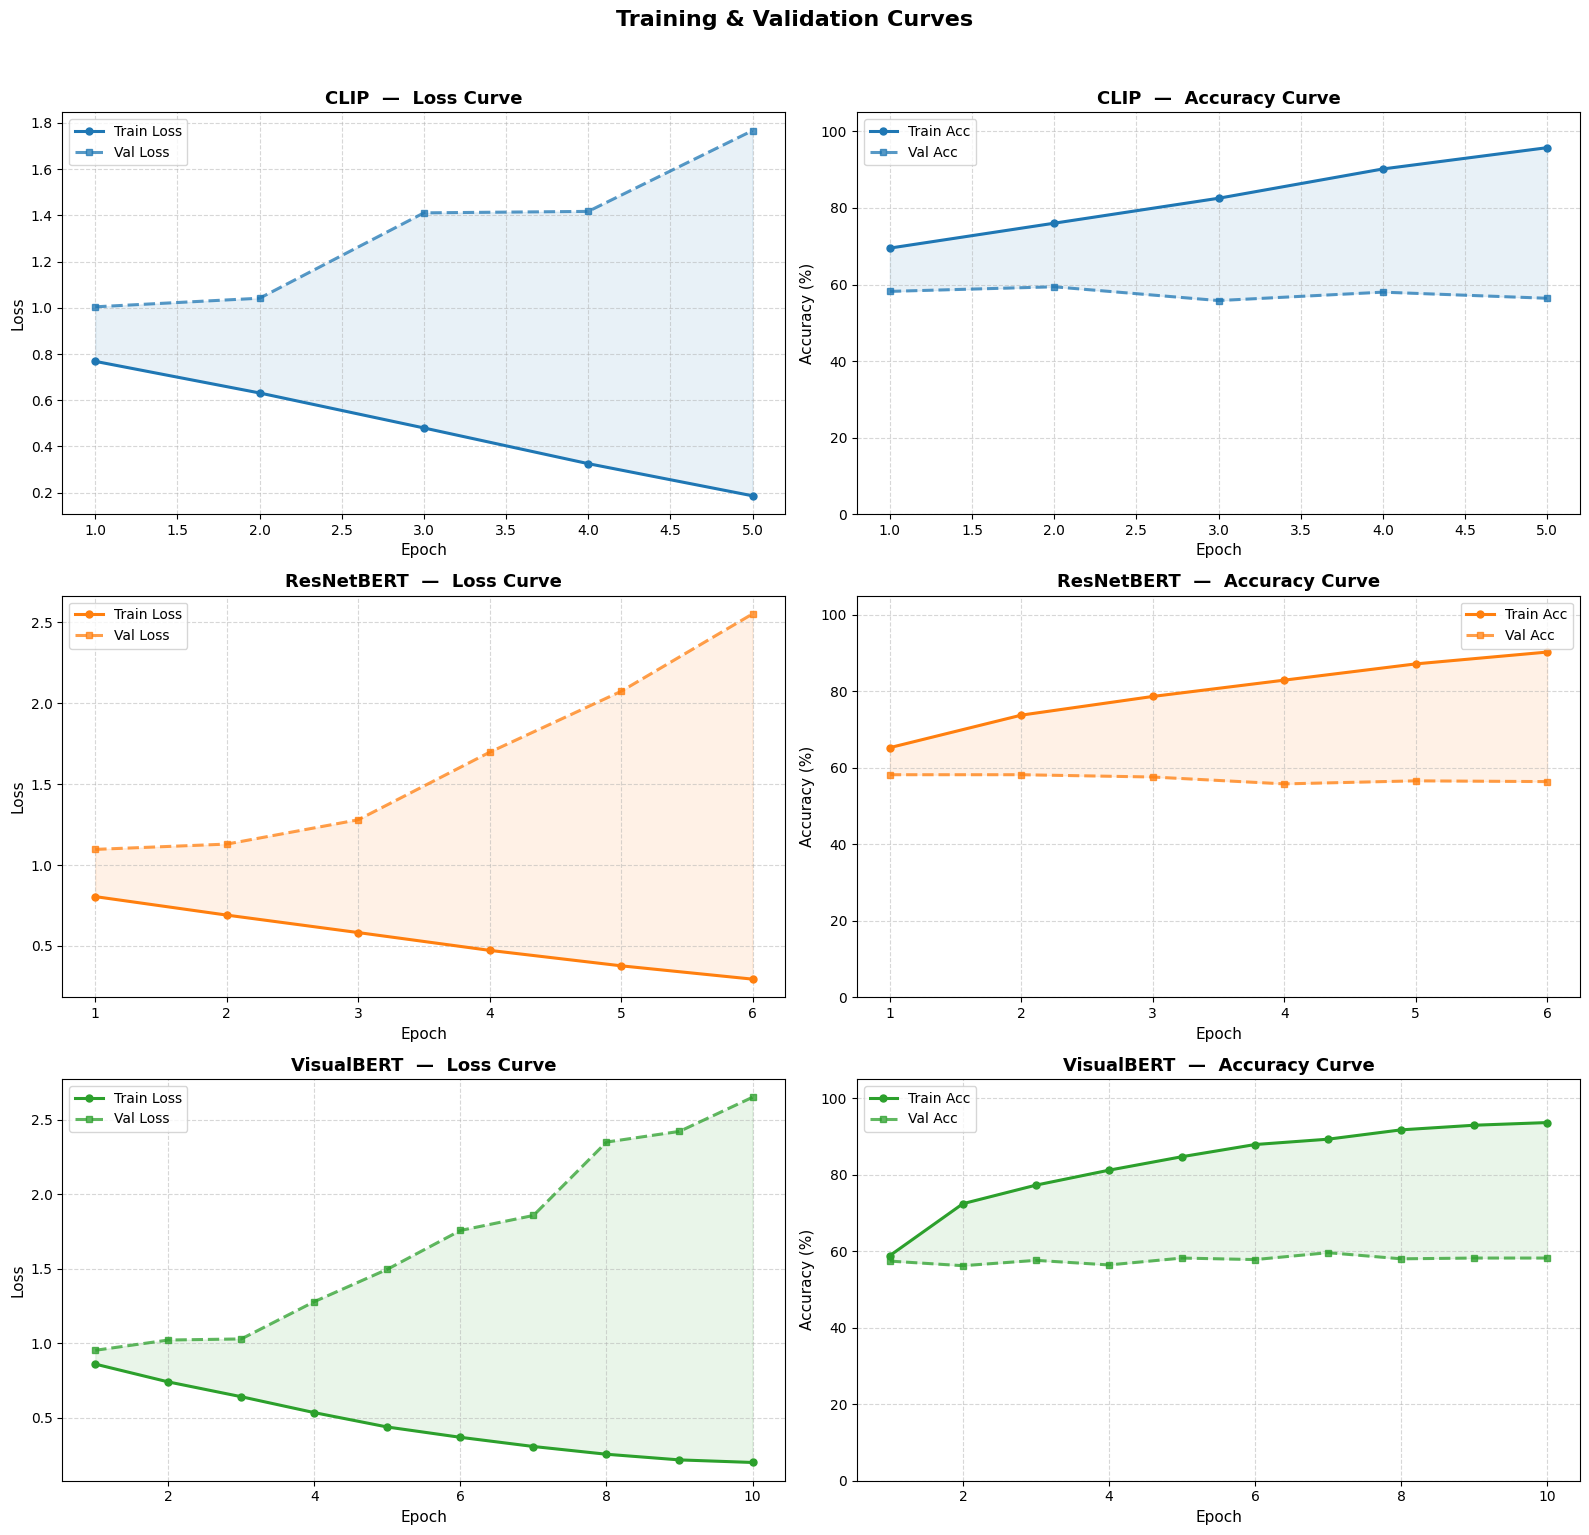

Saved → training_curves.png


In [13]:
def plot_training_curves(histories: dict):
    """Separate loss and accuracy curves for each model, side-by-side."""
    if not histories:
        print("No history to plot."); return

    n       = len(histories)
    palette = sns.color_palette("tab10", n)
    fig, axes = plt.subplots(n, 2, figsize=(16, 5 * n))
    if n == 1:
        axes = [axes]

    for i, (model_name, hist) in enumerate(histories.items()):
        color  = palette[i]
        epochs = range(1, len(hist['train_loss']) + 1)

        # — Loss ——————————————————————————————————————————————
        ax = axes[i][0]
        ax.plot(epochs, hist['train_loss'], 'o-',  color=color,
                label='Train Loss', linewidth=2.2, markersize=5)
        ax.plot(epochs, hist['val_loss'],   's--', color=color,
                label='Val Loss',   linewidth=2.2, markersize=5, alpha=0.75)
        ax.fill_between(epochs, hist['train_loss'], hist['val_loss'],
                         alpha=0.10, color=color)
        ax.set_title(f"{model_name}  —  Loss Curve",
                     fontsize=13, fontweight='bold')
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel("Loss",  fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)

        # — Accuracy ——————————————————————————————————————————
        ax = axes[i][1]
        t_acc_pct = [a * 100 for a in hist['train_acc']]
        v_acc_pct = [a * 100 for a in hist['val_acc']]
        ax.plot(epochs, t_acc_pct, 'o-',  color=color,
                label='Train Acc', linewidth=2.2, markersize=5)
        ax.plot(epochs, v_acc_pct, 's--', color=color,
                label='Val Acc',   linewidth=2.2, markersize=5, alpha=0.75)
        ax.fill_between(epochs, t_acc_pct, v_acc_pct,
                         alpha=0.10, color=color)
        ax.set_title(f"{model_name}  —  Accuracy Curve",
                     fontsize=13, fontweight='bold')
        ax.set_xlabel("Epoch",        fontsize=11)
        ax.set_ylabel("Accuracy (%)", fontsize=11)
        ax.set_ylim(0, 105)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle("Training & Validation Curves", fontsize=16,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → training_curves.png")

plot_training_curves(model_histories)

## 14. Visualization — Classification Reports

In [14]:
def print_classification_reports(histories: dict):
    """Print sklearn classification report for every trained model."""
    for model_name, hist in histories.items():
        print(f"\n{'='*55}")
        print(f"  Classification Report  —  {model_name}")
        print('='*55)
        print(classification_report(
            hist['y_true'], hist['y_pred'],
            target_names=['Non-Hateful (0)', 'Hateful (1)'],
            digits=4
        ))

print_classification_reports(model_histories)


  Classification Report  —  CLIP
                 precision    recall  f1-score   support

Non-Hateful (0)     0.5728    0.7400    0.6457       250
    Hateful (1)     0.6328    0.4480    0.5246       250

       accuracy                         0.5940       500
      macro avg     0.6028    0.5940    0.5852       500
   weighted avg     0.6028    0.5940    0.5852       500


  Classification Report  —  ResNetBERT
                 precision    recall  f1-score   support

Non-Hateful (0)     0.5503    0.8320    0.6624       250
    Hateful (1)     0.6557    0.3200    0.4301       250

       accuracy                         0.5760       500
      macro avg     0.6030    0.5760    0.5463       500
   weighted avg     0.6030    0.5760    0.5463       500


  Classification Report  —  VisualBERT
                 precision    recall  f1-score   support

Non-Hateful (0)     0.5584    0.7840    0.6522       250
    Hateful (1)     0.6376    0.3800    0.4762       250

       accuracy        

## 15. Visualization — Confusion Matrices

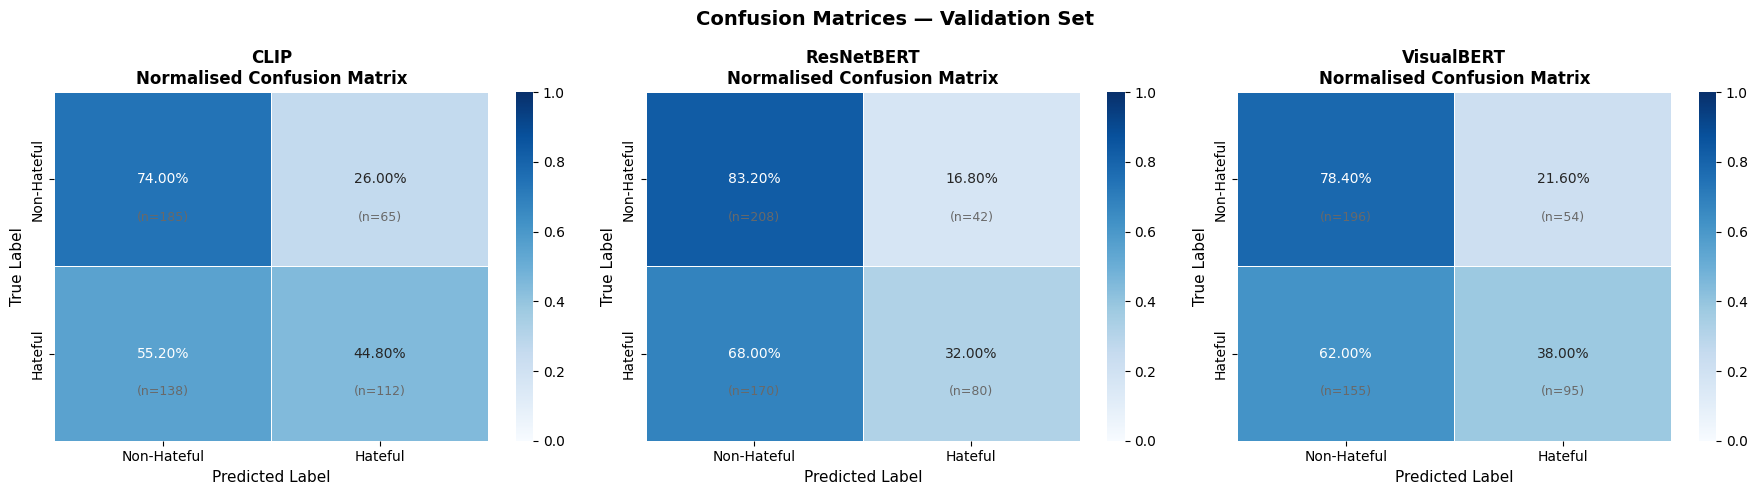

Saved → confusion_matrices.png


In [15]:
def plot_confusion_matrices(histories: dict):
    """Normalised confusion matrices with raw counts overlaid."""
    n    = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (model_name, hist) in zip(axes, histories.items()):
        cm      = confusion_matrix(hist['y_true'], hist['y_pred'])
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
            xticklabels=['Non-Hateful', 'Hateful'],
            yticklabels=['Non-Hateful', 'Hateful'],
            linewidths=0.5, vmin=0, vmax=1,
        )
        # Overlay raw counts in grey
        for r in range(2):
            for c in range(2):
                ax.text(c + 0.5, r + 0.72, f"(n={cm[r,c]})",
                        ha='center', va='center', fontsize=9, color='dimgrey')

        ax.set_title(f"{model_name}\nNormalised Confusion Matrix",
                     fontweight='bold', fontsize=12)
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label",      fontsize=11)

    plt.suptitle("Confusion Matrices — Validation Set",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → confusion_matrices.png")

plot_confusion_matrices(model_histories)

## 16. Visualization — ROC Curves

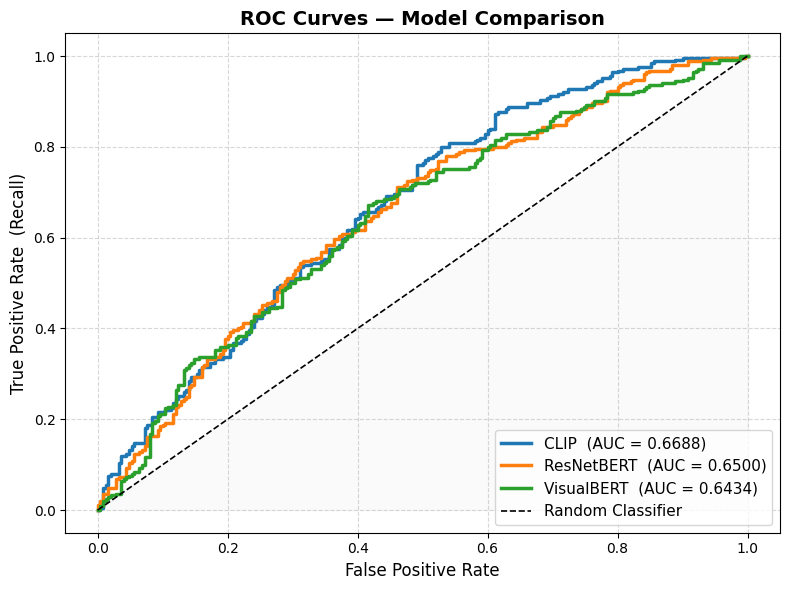

Saved → roc_curves.png


In [16]:
def plot_roc_curves(histories: dict):
    """Overlaid ROC curves for all models with AUC scores."""
    palette = sns.color_palette("tab10", len(histories))
    plt.figure(figsize=(8, 6))

    for color, (model_name, hist) in zip(palette, histories.items()):
        fpr, tpr, _ = roc_curve(hist['y_true'], hist['y_probs'])
        auc_v       = roc_auc_score(hist['y_true'], hist['y_probs'])
        plt.plot(fpr, tpr, linewidth=2.5, color=color,
                 label=f"{model_name}  (AUC = {auc_v:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier')
    plt.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')

    plt.xlabel("False Positive Rate",            fontsize=12)
    plt.ylabel("True Positive Rate  (Recall)",   fontsize=12)
    plt.title("ROC Curves — Model Comparison",   fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → roc_curves.png")

plot_roc_curves(model_histories)

## 17. Visualization — Precision-Recall Curves

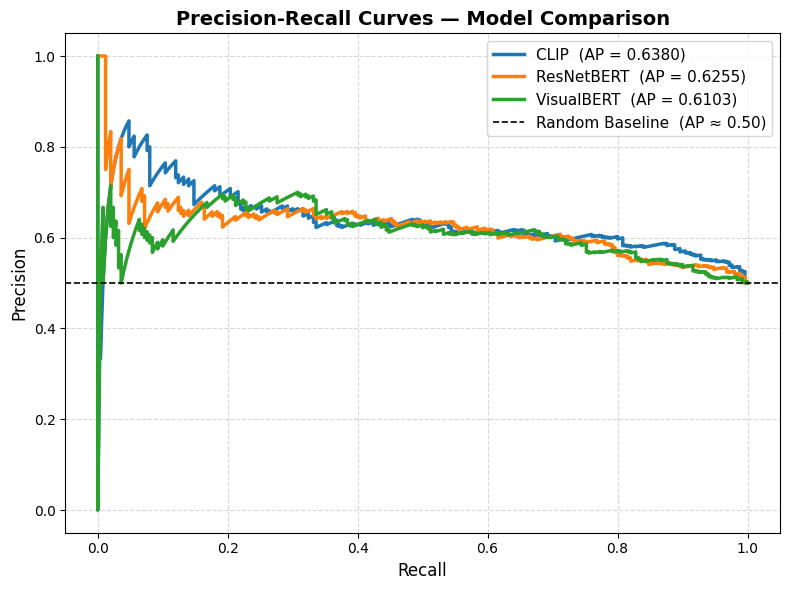

Saved → pr_curves.png


In [17]:
def plot_pr_curves(histories: dict):
    """Overlaid Precision-Recall curves with Average Precision scores."""
    palette = sns.color_palette("tab10", len(histories))
    plt.figure(figsize=(8, 6))

    first_hist = next(iter(histories.values()))
    baseline   = first_hist['y_true'].mean()   # random baseline

    for color, (model_name, hist) in zip(palette, histories.items()):
        prec, rec, _ = precision_recall_curve(hist['y_true'], hist['y_probs'])
        ap_val       = average_precision_score(hist['y_true'], hist['y_probs'])
        plt.plot(rec, prec, linewidth=2.5, color=color,
                 label=f"{model_name}  (AP = {ap_val:.4f})")

    plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1.2,
                label=f"Random Baseline  (AP ≈ {baseline:.2f})")

    plt.xlabel("Recall",    fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision-Recall Curves — Model Comparison",
              fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("pr_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → pr_curves.png")

plot_pr_curves(model_histories)

## 18. Visualization — Per-Model Metric Radar Chart

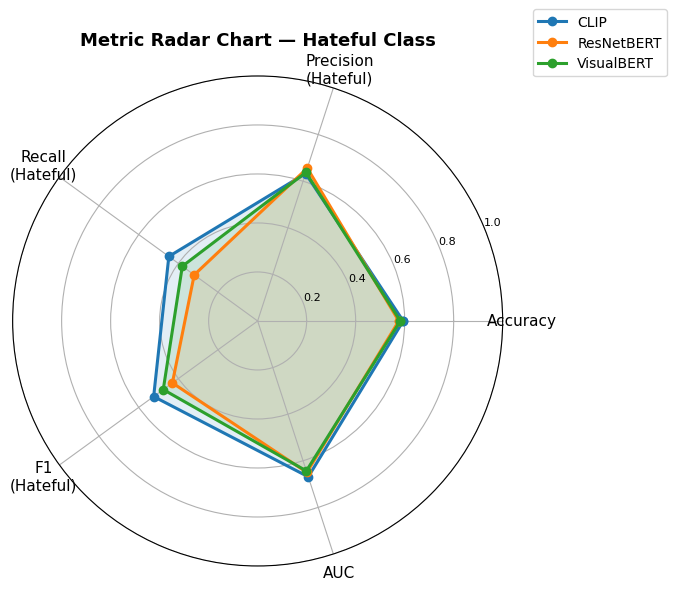

Saved → radar_chart.png


In [18]:
def plot_radar_chart(histories: dict):
    """Radar chart comparing 5 key metrics across all models."""
    metrics   = ['Accuracy', 'Precision\n(Hateful)', 'Recall\n(Hateful)',
                 'F1\n(Hateful)', 'AUC']
    n_metrics = len(metrics)
    angles    = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
    angles   += angles[:1]   # close the polygon

    palette = sns.color_palette("tab10", len(histories))
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for color, (model_name, hist) in zip(palette, histories.items()):
        acc   = accuracy_score(hist['y_true'],  hist['y_pred'])
        prec  = precision_score(hist['y_true'], hist['y_pred'], zero_division=0)
        rec   = recall_score(hist['y_true'],    hist['y_pred'], zero_division=0)
        f1v   = f1_score(hist['y_true'],        hist['y_pred'], zero_division=0)
        auc_v = roc_auc_score(hist['y_true'], hist['y_probs'])

        vals  = [acc, prec, rec, f1v, auc_v] + [acc]  # close polygon
        ax.plot(angles, vals, 'o-', linewidth=2.2, color=color, label=model_name)
        ax.fill(angles, vals, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)
    ax.set_title("Metric Radar Chart — Hateful Class",
                 fontsize=13, fontweight='bold', pad=22)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig("radar_chart.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → radar_chart.png")

plot_radar_chart(model_histories)

## 19. Visualization — Final Model Comparison


  FINAL MODEL COMPARISON
     Model  Accuracy    AUC     F1
      CLIP     0.594 0.6688 0.5246
ResNetBERT     0.576 0.6500 0.4301
VisualBERT     0.582 0.6434 0.4762


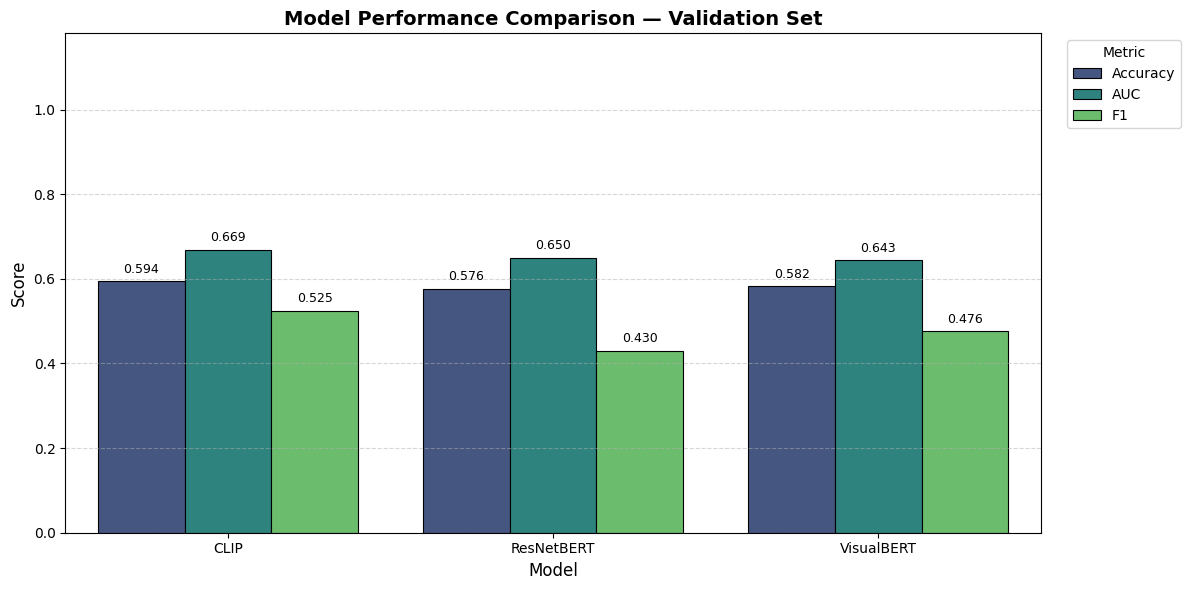

Saved → model_comparison.png


In [19]:
def plot_model_comparison(comp: dict):
    """Grouped bar chart comparing Accuracy, AUC, and F1 across models."""
    if not comp['Model']:
        print("No comparison data."); return

    results_df = pd.DataFrame(comp)
    print("\n" + "="*50)
    print("  FINAL MODEL COMPARISON")
    print("="*50)
    print(results_df.to_string(index=False))

    melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=melted, x='Model', y='Score', hue='Metric',
                     palette='viridis', edgecolor='black', linewidth=0.8)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9, padding=4)

    plt.title("Model Performance Comparison — Validation Set",
              fontsize=14, fontweight='bold')
    plt.ylim(0, 1.18)
    plt.ylabel("Score", fontsize=12)
    plt.xlabel("Model", fontsize=12)
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → model_comparison.png")

plot_model_comparison(model_comparison)

## 20. Summary Dashboard *(all key plots in one figure)*

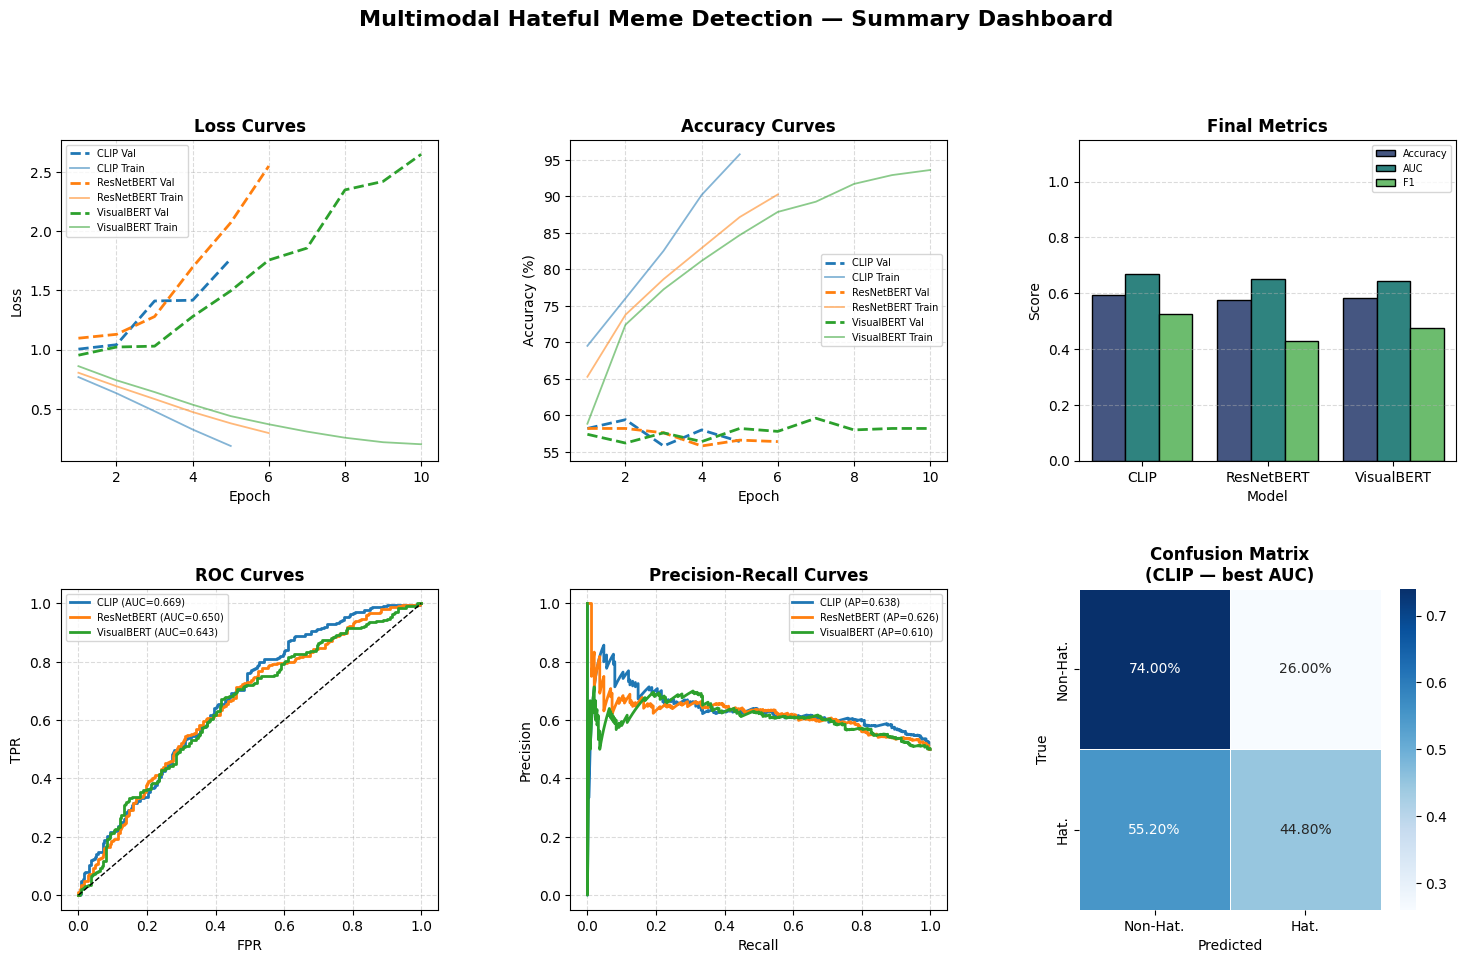

Saved → summary_dashboard.png


In [20]:
def plot_summary_dashboard(histories: dict, comp: dict):
    """
    Single 2×3 dashboard:
      Row 1: Loss curves (one per model, combined)
      Row 2: Accuracy curves | ROC | PR
    """
    if not histories:
        print("No history available."); return

    palette = sns.color_palette("tab10", len(histories))
    fig     = plt.figure(figsize=(18, 10))
    gs      = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

    ax_loss = fig.add_subplot(gs[0, 0])
    ax_acc  = fig.add_subplot(gs[0, 1])
    ax_bar  = fig.add_subplot(gs[0, 2])
    ax_roc  = fig.add_subplot(gs[1, 0])
    ax_pr   = fig.add_subplot(gs[1, 1])
    ax_cm   = fig.add_subplot(gs[1, 2])

    # ── Loss & Accuracy (all models on same axes) ────────────
    for color, (mname, hist) in zip(palette, histories.items()):
        ep = range(1, len(hist['train_loss']) + 1)
        ax_loss.plot(ep, hist['val_loss'],   '--', color=color,
                     label=f"{mname} Val",   linewidth=2)
        ax_loss.plot(ep, hist['train_loss'], '-',  color=color,
                     label=f"{mname} Train", linewidth=1.3, alpha=0.55)
        ax_acc.plot(ep, [a*100 for a in hist['val_acc']],   '--', color=color,
                    label=f"{mname} Val",   linewidth=2)
        ax_acc.plot(ep, [a*100 for a in hist['train_acc']], '-',  color=color,
                    label=f"{mname} Train", linewidth=1.3, alpha=0.55)

    for ax, title, ylabel in [
        (ax_loss, "Loss Curves",     "Loss"),
        (ax_acc,  "Accuracy Curves", "Accuracy (%)")
    ]:
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.45)

    # ── Bar chart ────────────────────────────────────────────
    if comp['Model']:
        melted = pd.DataFrame(comp).melt(id_vars='Model',
                                          var_name='Metric', value_name='Score')
        sns.barplot(data=melted, x='Model', y='Score', hue='Metric',
                    palette='viridis', ax=ax_bar, edgecolor='black')
        ax_bar.set_title("Final Metrics", fontweight='bold')
        ax_bar.set_ylim(0, 1.15); ax_bar.grid(axis='y', linestyle='--', alpha=0.45)
        ax_bar.legend(fontsize=7)

    # ── ROC ──────────────────────────────────────────────────
    for color, (mname, hist) in zip(palette, histories.items()):
        fpr, tpr, _ = roc_curve(hist['y_true'], hist['y_probs'])
        auc_v       = roc_auc_score(hist['y_true'], hist['y_probs'])
        ax_roc.plot(fpr, tpr, color=color, linewidth=2,
                    label=f"{mname} (AUC={auc_v:.3f})")
    ax_roc.plot([0,1],[0,1],'k--',linewidth=1)
    ax_roc.set_title("ROC Curves", fontweight='bold')
    ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
    ax_roc.legend(fontsize=7); ax_roc.grid(True,linestyle='--',alpha=0.45)

    # ── PR ───────────────────────────────────────────────────
    for color, (mname, hist) in zip(palette, histories.items()):
        prec, rec, _ = precision_recall_curve(hist['y_true'], hist['y_probs'])
        ap_v         = average_precision_score(hist['y_true'], hist['y_probs'])
        ax_pr.plot(rec, prec, color=color, linewidth=2,
                   label=f"{mname} (AP={ap_v:.3f})")
    ax_pr.set_title("Precision-Recall Curves", fontweight='bold')
    ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=7); ax_pr.grid(True,linestyle='--',alpha=0.45)

    # ── Best model confusion matrix ──────────────────────────
    if comp['Model']:
        best_model = comp['Model'][np.argmax(comp['AUC'])]
        hist       = histories[best_model]
        cm         = confusion_matrix(hist['y_true'], hist['y_pred'])
        cm_norm    = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax_cm,
                    xticklabels=['Non-Hat.','Hat.'],
                    yticklabels=['Non-Hat.','Hat.'], linewidths=0.5)
        ax_cm.set_title(f"Confusion Matrix\n({best_model} — best AUC)",
                        fontweight='bold')
        ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("True")

    plt.suptitle("Multimodal Hateful Meme Detection — Summary Dashboard",
                 fontsize=16, fontweight='bold', y=1.01)
    plt.savefig("summary_dashboard.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → summary_dashboard.png")

plot_summary_dashboard(model_histories, model_comparison)